Root cause analysis for changes in ΔT2 and ΔTc

In [8]:
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xwrf
import seaborn as sns

In [ ]:
run_dir = '/project2/zhan248_1326/hhao4018/WRFv4.6.1_Modified_AHoption_noChem/test'
simulations = {
    "target": {
        "summer": "JOE_Default_08_ah=2_GDAS_frac_urb_v2",
        "winter": "JOE_Default_12_ah=2_GDAS_frac_urb_v2",
    },
    "control": {
        "summer": "JOE_Default_2016_08_ah=0_v2",
        "winter": "JOE_Default_2016_12_ah=0_v2",
    }
}

In [22]:
sample_file = '/project2/zhan248_1326/hhao4018/WRFv4.6.1_Modified_AHoption_noChem/test/JOE_Default_08_ah=2_GDAS_frac_urb_v2/wrfout_d02_2016-08-12_18:00:00'
ds_test = xr.open_dataset(sample_file).xwrf.postprocess()
ds_test

<xarray.Dataset> Size: 76MB
Dimensions:                    (Time: 1, y: 192, x: 244, z: 44,
                                urban_wind_directions_stag: 4, z_stag: 45)
Coordinates:
  * Time                       (Time) datetime64[us] 8B 2016-08-12T18:00:00
    XTIME                      (Time) datetime64[ns] 8B ...
  * y                          (y) float64 2kB -4.254e+05 ... -2.344e+05
  * x                          (x) float64 2kB 1.325e+05 1.335e+05 ... 3.755e+05
    XLAT                       (y, x) float32 187kB 33.25 33.25 ... 34.92 34.92
    XLONG                      (y, x) float32 187kB -119.1 -119.0 ... -116.3
Dimensions without coordinates: z, urban_wind_directions_stag, z_stag
Data variables: (12/99)
    Times                      (Time) |S19 19B b'2016-08-12_18:00:00'
    LU_INDEX                   (Time, y, x) float32 187kB ...
    Q2                         (Time, y, x) float32 187kB ...
    T2                         (Time, y, x) float32 187kB ...
    PSFC                       (Time, y, x) float32 187kB ...
    U10                        (Time, y, x) float32 187kB ...
    ...                         ...
    LANDMASK                   (Time, y, x) float32 187kB ...
    LAKEMASK                   (Time, y, x) float32 187kB ...
    SST                        (Time, y, x) float32 187kB ...
    SST_INPUT                  (Time, y, x) float32 187kB ...
    air_potential_temperature  (Time, z, y, x) float32 8MB 288.2 288.3 ... 408.5
    wrf_projection             object 8B +proj=lcc +x_0=0 +y_0=0 +a=6370000 +...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2016-08-10_00:00:00
    SIMULATION_START_DATE:           2016-08-10_00:00:00
    WEST-EAST_GRID_DIMENSION:        245
    SOUTH-NORTH_GRID_DIMENSION:      193
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [12]:
# import deltas data
deltas = {}
data_dir = '/home1/kojoseph/ah-la-paper/data/deltas-urban-wrf-v7'
nc_files = glob.glob(f"{data_dir}/*.nc")
for f in nc_files:
    filename = os.path.basename(f)
    delta_id = filename.split('.')[0]
    ds = xr.open_dataset(f)
    deltas[delta_id] = ds
deltas

{'ah_off-ah_elec_low-12': <xarray.Dataset> Size: 59MB
 Dimensions:      (Time: 168, y: 124, x: 117)
 Coordinates:
   * Time         (Time) datetime64[ns] 1kB 2016-12-12 ... 2016-12-18T23:00:00
     hour         (Time) int64 1kB ...
   * y            (y) float64 992B -3.744e+05 -3.734e+05 ... -2.514e+05
   * x            (x) float64 936B 1.415e+05 1.425e+05 ... 2.565e+05 2.575e+05
     XLAT         (y, x) float32 58kB ...
     XLONG        (y, x) float32 58kB ...
 Data variables:
     spatial_ref  int64 8B ...
     T2           (Time, y, x) float32 10MB ...
     TC_URB       (Time, y, x) float32 10MB ...
     WS           (Time, y, x) float32 10MB ...
     PBLH         (Time, y, x) float32 10MB ...
     FRC_URB2D    (Time, y, x) float32 10MB ...
     AHFLUX       (Time, y, x) float32 10MB ...,
 'ah_default-ah_elec_medium-08': <xarray.Dataset> Size: 59MB
 Dimensions:      (Time: 168, y: 124, x: 117)
 Coordinates:
   * Time         (Time) datetime64[ns] 1kB 2016-08-12 ... 2016-08-18T23:00

In [13]:
deltas.keys()

dict_keys(['ah_off-ah_elec_low-12', 'ah_default-ah_elec_medium-08', 'ah_off-ah_elec_medium-12', 'ah_default-ah_elec_low-08', 'ah_default-ah_elec_high-08', 'ah_off-ah_elec_high-08', 'ah_off-ah_default-12', 'ah_default-ah_elec_medium-12', 'ah_off-ah_elec_low-08', 'ah_default-ah_elec_low-12', 'ah_off-ah_elec_medium-08', 'ah_default-ah_elec_high-12', 'ah_off-ah_default-08', 'ah_off-ah_elec_high-12'])

In [3]:
# test on one experiment 
exp = "JOE_Default_08_ah=2_GDAS_frac_urb_v2"
out_dir = os.path.join(run_dir, exp)
# pattern for all wrfout_d02 files
filelist = sorted(glob.glob(os.path.join(out_dir, "wrfout_d02*")))

ds = xr.open_mfdataset(filelist, 
                    engine="netcdf4",
                    concat_dim="Time",
                    combine="nested").xwrf.postprocess()
ds

<xarray.Dataset> Size: 16GB
Dimensions:                    (Time: 217, y: 192, x: 244, z: 44,
                                urban_wind_directions_stag: 4, z_stag: 45)
Coordinates:
  * Time                       (Time) datetime64[us] 2kB 2016-08-10 ... 2016-...
    XTIME                      (Time) datetime64[ns] 2kB dask.array<chunksize=(1,), meta=np.ndarray>
  * y                          (y) float64 2kB -4.254e+05 ... -2.344e+05
  * x                          (x) float64 2kB 1.325e+05 1.335e+05 ... 3.755e+05
    XLAT                       (y, x) float32 187kB dask.array<chunksize=(192, 244), meta=np.ndarray>
    XLONG                      (y, x) float32 187kB dask.array<chunksize=(192, 244), meta=np.ndarray>
Dimensions without coordinates: z, urban_wind_directions_stag, z_stag
Data variables: (12/99)
    Times                      (Time) |S19 4kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    Q2                         (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    T2                         (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    PSFC                       (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    U10                        (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    ...                         ...
    LANDMASK                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    LAKEMASK                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    SST                        (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    SST_INPUT                  (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    air_potential_temperature  (Time, z, y, x) float32 2GB dask.array<chunksize=(1, 44, 192, 244), meta=np.ndarray>
    wrf_projection             object 8B +proj=lcc +x_0=0 +y_0=0 +a=6370000 +...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2016-08-10_00:00:00
    SIMULATION_START_DATE:           2016-08-10_00:00:00
    WEST-EAST_GRID_DIMENSION:        245
    SOUTH-NORTH_GRID_DIMENSION:      193
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [4]:
# print all variables to txt file 
out_dir = "../data"
output_file = os.path.join(out_dir, "wrf_variables.txt")

with open(output_file, "w") as f:
    f.write("=== DATA VARIABLES ===\n\n")
    for var in ds.data_vars:
        f.write(f"{var}\n")
        for attr, val in ds[var].attrs.items():
            f.write(f"  {attr}: {val}\n")
        f.write("\n")

    f.write("\n=== COORDINATES ===\n\n")
    for coord in ds.coords:
        f.write(f"{coord}\n")
        for attr, val in ds[coord].attrs.items():
            f.write(f"  {attr}: {val}\n")
        f.write("\n")

print(f"Saved to: {output_file}")

Saved to: ../data/wrf_variables.txt


In [23]:
def compute_diurnal_cycle(exp_name, varname, urban_mask_xr, reduce_method="surface"):
    """
    Generic diurnal cycle computation for WRF variables or derived variables.

    varname can be:
        - string: "LH", "PBLH", etc.
        - special: "delta_T_canopy", "delta_T_surface"
    """

    out_dir = os.path.join(run_dir, exp_name)
    filelist = sorted(glob.glob(os.path.join(out_dir, "wrfout_d02*")))

    ds = xr.open_mfdataset(
        filelist,
        engine="netcdf4",
        concat_dim="Time",
        combine="nested"
    ).xwrf.postprocess()

    # ---- Convert UTC → Pacific ----
    time_local = pd.to_datetime(ds["Time"].values)\
        .tz_localize("UTC")\
        .tz_convert("America/Los_Angeles")\
        .tz_localize(None)

    ds = ds.assign_coords(Time=time_local)

    # ---- Handle derived variables ----
    if varname == "delta_T_canopy":
        var = ds["TS_URB"] - ds["TC_URB"]

    elif varname == "delta_T_surface":
        var = ds["TSK"] - ds["T2"]
    
    elif varname == 'delta_Tc_T2':
        var = ds['TC_URB'] - ds['T2']

    else:
        if varname not in ds:
            raise ValueError(f"{varname} not found in dataset")
        var = ds[varname]

    # ---- Handle extra dimensions ----
    spatial_dims = {"Time", "y", "x"}
    extra_dims = [d for d in var.dims if d not in spatial_dims]

    if extra_dims:
        if reduce_method == "surface":
            for d in extra_dims:
                var = var.isel({d: 0})
        elif reduce_method == "mean":
            var = var.mean(dim=extra_dims)
        else:
            raise ValueError("reduce_method must be 'surface' or 'mean'")

    # ---- Apply urban mask ----
    var = var.where(urban_mask_xr)

    # ---- Diurnal cycle ----
    grouped = var.groupby("Time.hour")

    mean = grouped.mean(dim=["Time", "y", "x"])
    std = grouped.std(dim=["Time", "y", "x"])

    return mean.compute(), std.compute()

In [6]:
urban_mask_path = '/home1/kojoseph/ah-la-paper/data/urban_mask/wrf_urban_mask-v4.gpkg'

# -----------------------------
# Build urban mask ONCE
# -----------------------------
# Use one dataset just to get grid
sample_exp = simulations["control"]["summer"]
sample_dir = os.path.join(run_dir, sample_exp)
sample_files = sorted(glob.glob(os.path.join(sample_dir, "wrfout_d02*")))

ds_sample = xr.open_mfdataset(
    sample_files,
    engine="netcdf4",
    concat_dim="Time",
    combine="nested"
).xwrf.postprocess()

lats = ds_sample["XLAT"].values
lons = ds_sample["XLONG"].values
ny, nx = lats.shape

# Build point GeoDataFrame
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lons.ravel(), lats.ravel()),
    crs="EPSG:4326"
)

# Load and align mask CRS
urban_mask = gpd.read_file(urban_mask_path).to_crs("EPSG:4326")

# Spatial join (ONLY ONCE)
joined = gpd.sjoin(points, urban_mask, predicate="intersects")

# Build boolean mask
mask_flat = np.zeros(lats.size, dtype=bool)
mask_flat[joined.index] = True
mask_2d = mask_flat.reshape(ny, nx)

# Convert to xarray DataArray
urban_mask_xr = xr.DataArray(mask_2d, dims=("y", "x"))

print("Urban cells:", mask_2d.sum())


Urban cells: 2208


# Latent Heat 

Urban cells: 2208


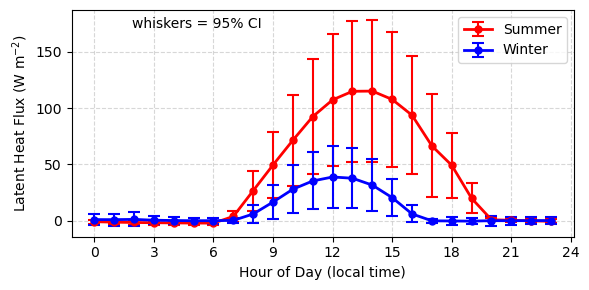

In [ ]:
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], 'LH', urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], 'LH', urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,3))

hours = mean_summer["hour"].values

# ---- Plot with caps + thicker lines ----
plt.errorbar(
    hours, mean_summer, yerr=std_summer,
    fmt='o-', color='red', ecolor='red',
    elinewidth=1.5, capsize=4, capthick=1.5,
    markersize=5, linewidth=2,
    label="Summer"
)

plt.errorbar(
    hours, mean_winter, yerr=std_winter,
    fmt='o-', color='blue', ecolor='blue',
    elinewidth=1.5, capsize=4, capthick=1.5,
    markersize=5, linewidth=2,
    label="Winter"
)

# ---- Axes formatting ----
plt.xlabel("Hour of Day (local time)")
plt.ylabel("Latent Heat Flux (W m$^{-2}$)")

# ticks every 3 hours
plt.xticks(np.arange(0, 25, 3))

# match clean paper style
plt.grid(True, linestyle='--', alpha=0.5)

# optional: tighten y limits if needed
# plt.ylim(bottom=0)

plt.legend(frameon=True)

# annotation like Figure 5
plt.text(0.25, 0.92, "whiskers = 95% CI",
         transform=plt.gca().transAxes,
         ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# PBL

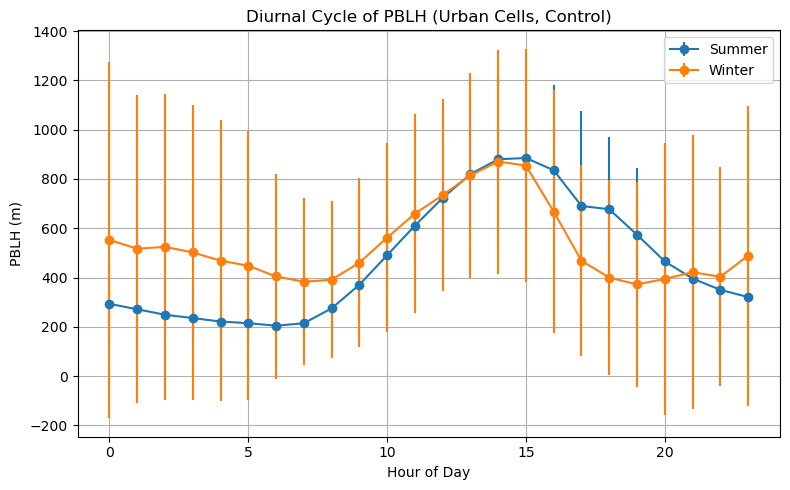

In [20]:
variable = 'PBLH'
variable_units = 'm'
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Wind

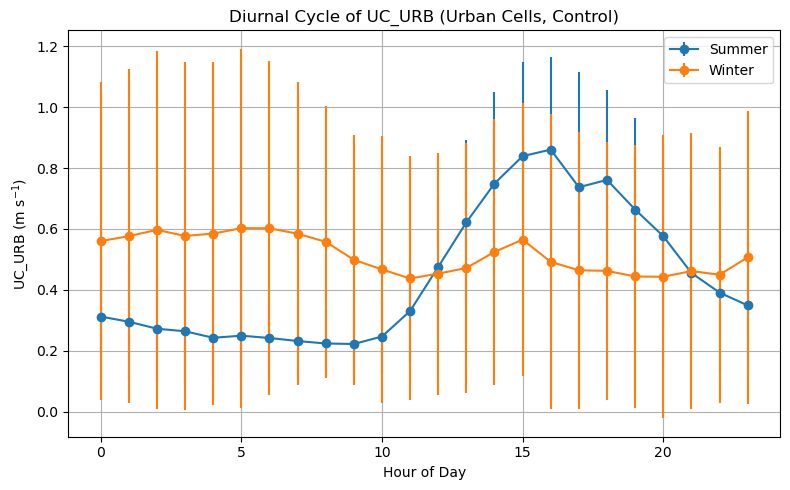

In [21]:
variable = 'UC_URB'
variable_units = r"m s$^{-1}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Turbulence / Mixing

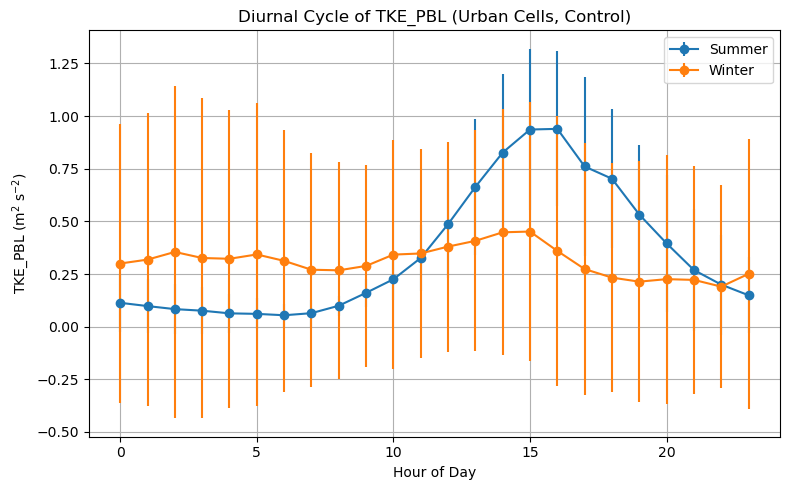

In [24]:
variable = 'TKE_PBL'
variable_units = r"m$^{2}$ s$^{-2}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Friction Velocity

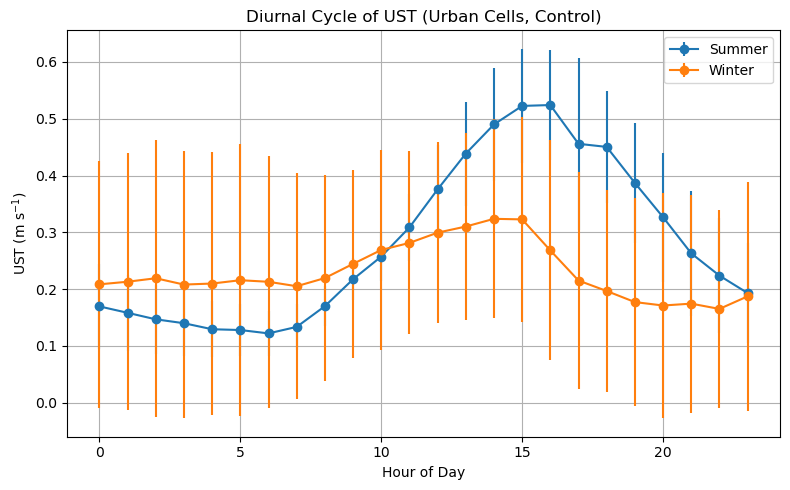

In [25]:
variable = 'UST'
variable_units = r"m s$^{-1}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Ts - Ta

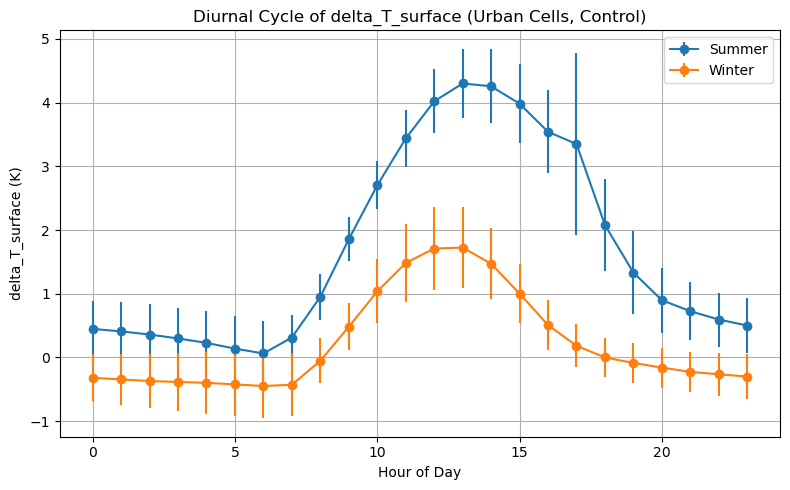

In [27]:
variable = 'delta_T_surface'
variable_units = r"K"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Tc - T2

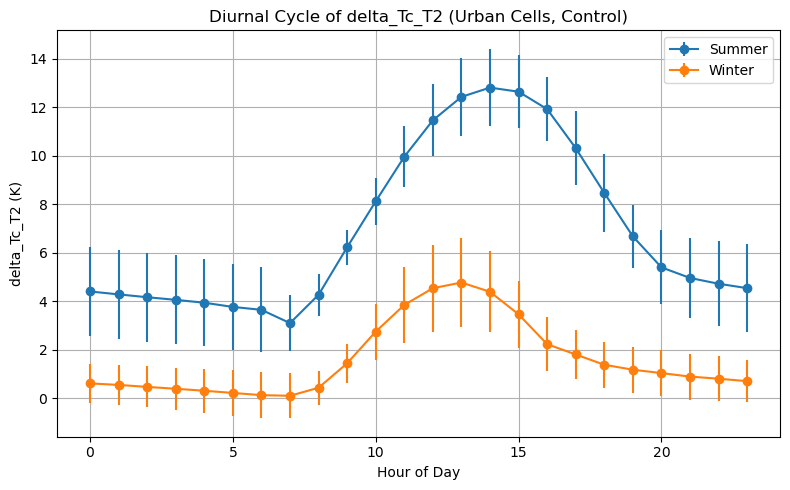

In [24]:
variable = 'delta_Tc_T2'
variable_units = r"K"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Correlation Heatmap

In [14]:
def compute_delta_diurnal_from_dict(ds, varname):
    """
    Compute hourly mean + std for delta variables (already urban-masked).

    Parameters
    ----------
    ds : xr.Dataset
        Delta dataset (from wrf_deltas dict)
    varname : str
        "T2" or "TC_URB" (these are already ΔT variables)

    Returns
    -------
    mean, std : xr.DataArray (hour)
    """

    if varname not in ds:
        raise ValueError(f"{varname} not found in dataset")

    var = ds[varname]

    # -----------------------------
    # Group by hour (already provided)
    # -----------------------------
    if "hour" in ds.coords:
        grouped = var.groupby(ds["hour"])
    else:
        grouped = var.groupby("Time.hour")

    # -----------------------------
    # Average over space + time
    # (skip NaNs automatically)
    # -----------------------------
    mean = grouped.mean(dim=["Time", "y", "x"], skipna=True)
    std = grouped.std(dim=["Time", "y", "x"], skipna=True)

    # Ensure full 0–23 hours
    mean = mean.reindex(hour=np.arange(24))
    std = std.reindex(hour=np.arange(24))

    return mean, std

In [15]:
def build_hourly_df(exp_name):
    vars_needed = [
        "T2", "TC_URB", "TSK", "TS_URB",
        "LH", "PBLH", "UST", "UC_URB"
    ]
    
    data = {}

    for v in vars_needed:
        mean, _ = compute_diurnal_cycle(exp_name, v, urban_mask_xr)
        data[v] = mean.values

    # derived variables
    data["delta_T_surface"] = (
        data["TSK"] - data["T2"]
    )

    data["hour"] = mean["hour"].values

    return pd.DataFrame(data)

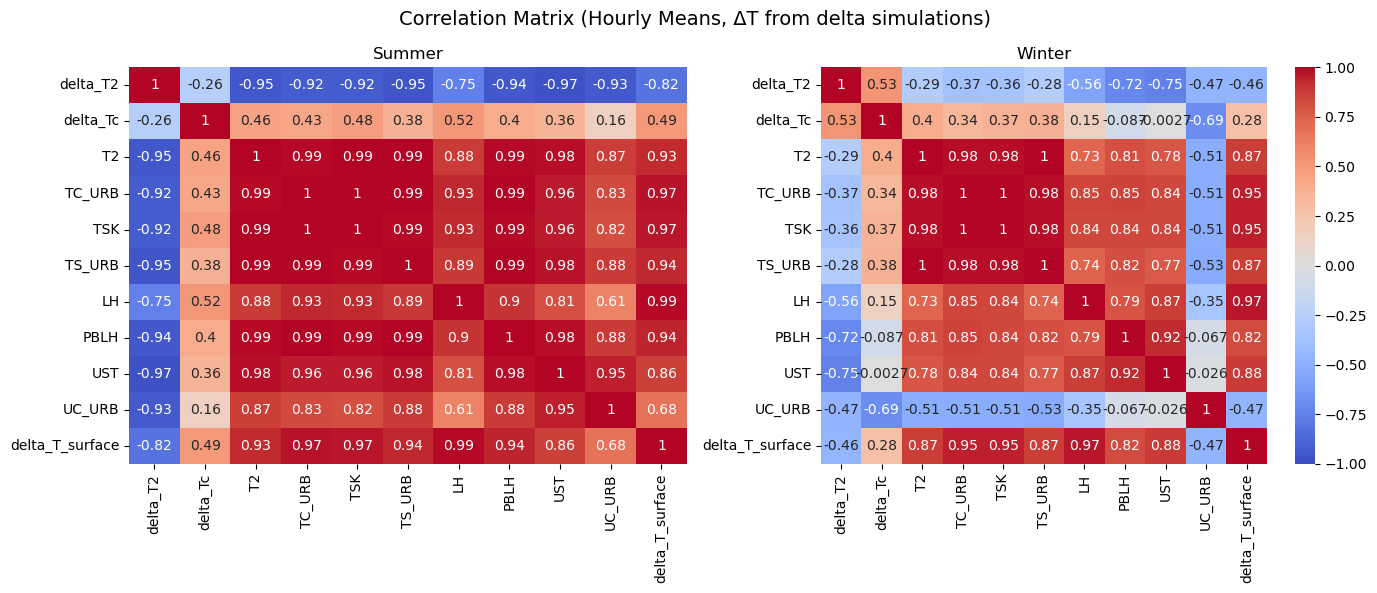

In [18]:
# -----------------------------
# Build base datasets (background state)
# -----------------------------
df_summer = build_hourly_df(simulations["control"]["summer"])
df_winter = build_hourly_df(simulations["control"]["winter"])

# -----------------------------
# Compute correct ΔT from delta files
# -----------------------------
ds_summer = deltas['ah_off-ah_default-08']
ds_winter = deltas['ah_off-ah_default-12']

# ΔT2
mean_T2_summer, _ = compute_delta_diurnal_from_dict(ds_summer, "T2")
mean_T2_winter, _ = compute_delta_diurnal_from_dict(ds_winter, "T2")

# ΔTc
mean_Tc_summer, _ = compute_delta_diurnal_from_dict(ds_summer, "TC_URB")
mean_Tc_winter, _ = compute_delta_diurnal_from_dict(ds_winter, "TC_URB")

# -----------------------------
# Insert correct ΔT into dataframes
# -----------------------------
df_summer["delta_T2"] = mean_T2_summer.values
df_summer["delta_Tc"] = mean_Tc_summer.values

df_winter["delta_T2"] = mean_T2_winter.values
df_winter["delta_Tc"] = mean_Tc_winter.values

# -----------------------------
# (Optional but recommended) reorder columns
# -----------------------------
cols_order = [
    "delta_T2", "delta_Tc",
    "T2", "TC_URB", "TSK", "TS_URB",
    "LH", "PBLH", "UST", "UC_URB",
    "delta_T_surface",
    "hour"
]

df_summer = df_summer[[c for c in cols_order if c in df_summer.columns]]
df_winter = df_winter[[c for c in cols_order if c in df_winter.columns]]

# -----------------------------
# Correlation matrices
# -----------------------------
corr_summer = df_summer.drop(columns="hour").corr()
corr_winter = df_winter.drop(columns="hour").corr()

# -----------------------------
# Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---- Summer ----
sns.heatmap(
    corr_summer,
    ax=axes[0],
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    cbar=False
)
axes[0].set_title("Summer")

# ---- Winter ----
sns.heatmap(
    corr_winter,
    ax=axes[1],
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    cbar=True
)
axes[1].set_title("Winter")

plt.suptitle("Correlation Matrix (Hourly Means, ΔT from delta simulations)", fontsize=14)

plt.tight_layout()
plt.show()

# Correlation barplots

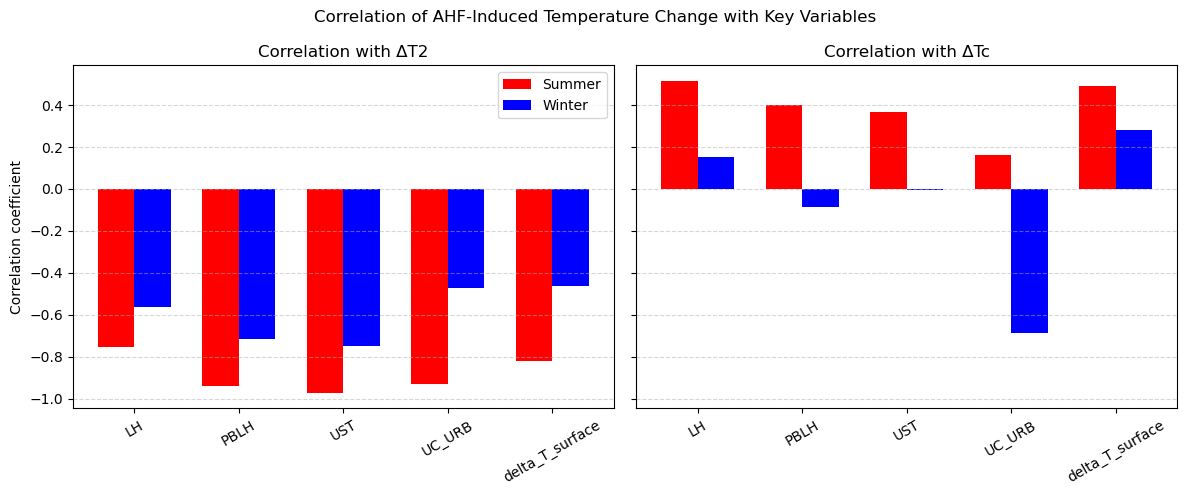

In [19]:
# variables of interest
vars_interest = ["LH", "PBLH", "UST", "UC_URB", "delta_T_surface"]

def get_corr_series(df, target):
    corr = df.drop(columns="hour").corr()
    return corr.loc[vars_interest, target]

# -----------------------------
# Compute correlations
# -----------------------------
corr_T2_summer = get_corr_series(df_summer, "delta_T2")
corr_T2_winter = get_corr_series(df_winter, "delta_T2")

corr_Tc_summer = get_corr_series(df_summer, "delta_Tc")
corr_Tc_winter = get_corr_series(df_winter, "delta_Tc")

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(vars_interest))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# ---- ΔT2 ----
axes[0].bar(x - width/2, corr_T2_summer, width, label="Summer", color="red")
axes[0].bar(x + width/2, corr_T2_winter, width, label="Winter", color="blue")

axes[0].set_xticks(x)
axes[0].set_xticklabels(vars_interest, rotation=30)
axes[0].set_title("Correlation with ΔT2")
axes[0].set_ylabel("Correlation coefficient")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[0].legend()

# ---- ΔTc ----
axes[1].bar(x - width/2, corr_Tc_summer, width, label="Summer", color="red")
axes[1].bar(x + width/2, corr_Tc_winter, width, label="Winter", color="blue")

axes[1].set_xticks(x)
axes[1].set_xticklabels(vars_interest, rotation=30)
axes[1].set_title("Correlation with ΔTc")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Correlation of AHF-Induced Temperature Change with Key Variables")

plt.tight_layout()
plt.show()

# Seasonal differences of driving features

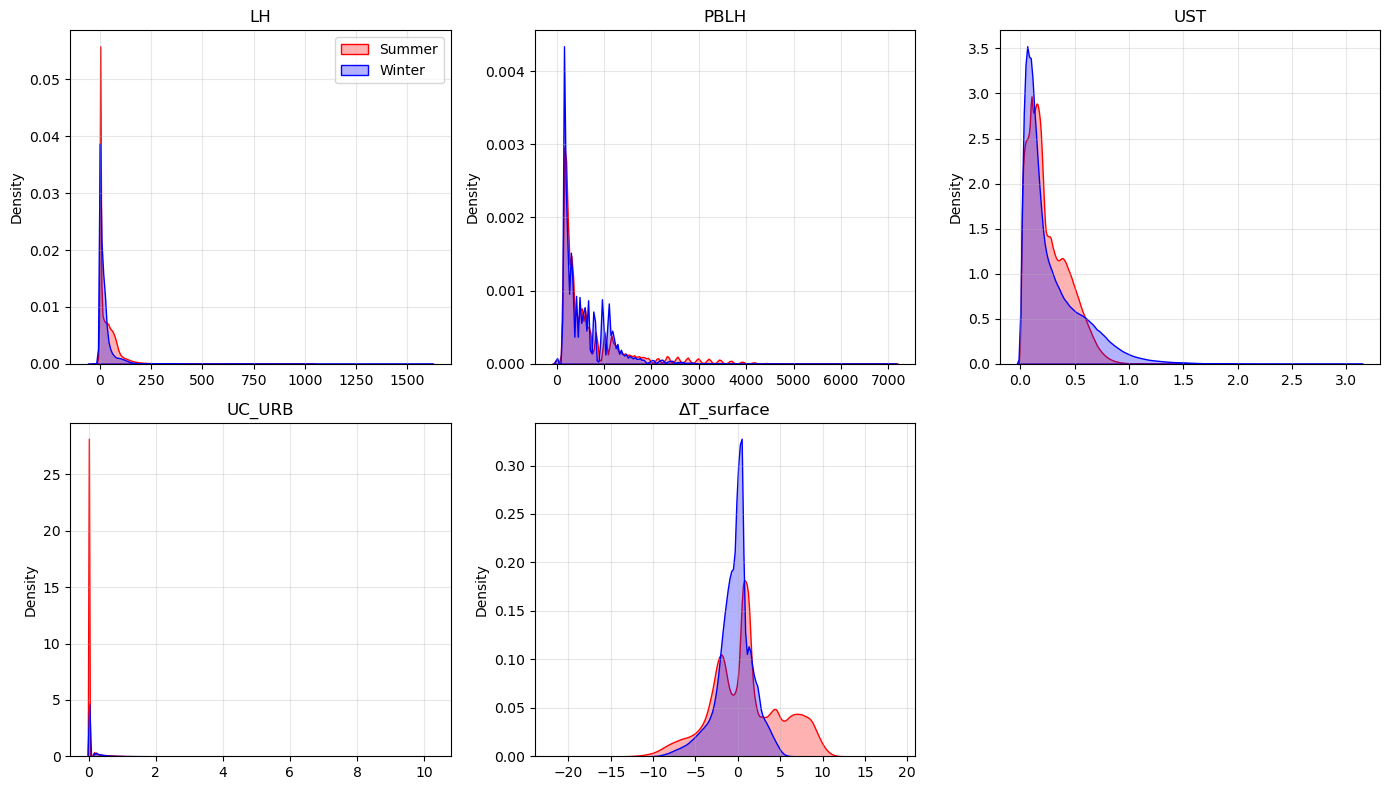

In [20]:
# -----------------------------
# Helper function to load data
# -----------------------------
def load_dataset(exp_name):
    out_dir = os.path.join(run_dir, exp_name)
    filelist = sorted(glob.glob(os.path.join(out_dir, "wrfout_d02*")))

    ds = xr.open_mfdataset(
        filelist,
        engine="netcdf4",
        concat_dim="Time",
        combine="nested"
    ).xwrf.postprocess()

    return ds

# -----------------------------
# Load datasets
# -----------------------------
ds_summer = load_dataset(simulations["target"]["summer"])
ds_winter = load_dataset(simulations["target"]["winter"])

# -----------------------------
# Extract variables
# -----------------------------
def extract_vars(ds):
    LH = ds["LH"]
    PBLH = ds["PBLH"]
    UST = ds["UST"]
    UC_URB = ds["UC_URB"]

    # Convert T2 from K → °C
    T2 = ds["T2"] - 273.15
    TSK = ds["TSK"] - 273.15

    delta_T_surface = TSK - T2

    return {
        "LH": LH,
        "PBLH": PBLH,
        "UST": UST,
        "UC_URB": UC_URB,
        "ΔT_surface": delta_T_surface
    }

vars_summer = extract_vars(ds_summer)
vars_winter = extract_vars(ds_winter)

# -----------------------------
# Flatten helper
# -----------------------------
def flatten(da):
    return da.values.flatten()

# -----------------------------
# Plot settings
# -----------------------------
variables = ["LH", "PBLH", "UST", "UC_URB", "ΔT_surface"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# -----------------------------
# Plot distributions
# -----------------------------
for i, var in enumerate(variables):
    ax = axes[i]

    data_summer = flatten(vars_summer[var])
    data_winter = flatten(vars_winter[var])

    # Remove NaNs
    data_summer = data_summer[~np.isnan(data_summer)]
    data_winter = data_winter[~np.isnan(data_winter)]

    # KDE plots
    sns.kdeplot(data_summer, ax=ax, color='red', label='Summer', fill=True, alpha=0.3)
    sns.kdeplot(data_winter, ax=ax, color='blue', label='Winter', fill=True, alpha=0.3)

    ax.set_title(var)
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

# Remove empty subplot (since 5 variables)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()